In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats



In [17]:
#prices1 = pd.read_csv('../prices_round_2_day_-1.csv', sep=';')
data= pd.read_csv("../prices_round_2_day_-1.csv", sep=";", index_col="timestamp")
#prices3 = pd.read_csv('../prices_round_2_day_1.csv', sep=';')

In [7]:
data

,day,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
timestamp,,,,,,,,,,,,,,,,
0,-1,INTARIAN_PEPPER_ROOT,10994.0,9.0,NaN,NaN,NaN,NaN,11009.0,25.0,NaN,NaN,NaN,NaN,11001.5,0.0
0,-1,ASH_COATED_OSMIUM,9982.0,21.0,NaN,NaN,NaN,NaN,10000.0,13.0,10003.0,21.0,NaN,NaN,9991.0,0.0
100,-1,ASH_COATED_OSMIUM,9984.0,15.0,NaN,NaN,NaN,NaN,10000.0,15.0,10003.0,26.0,NaN,NaN,9992.0,0.0
100,-1,INTARIAN_PEPPER_ROOT,10994.0,8.0,10991.0,22.0,NaN,NaN,11006.0,8.0,11009.0,22.0,NaN,NaN,11000.0,0.0
200,-1,ASH_COATED_OSMIUM,9985.0,15.0,9982.0,30.0,NaN,NaN,10001.0,15.0,NaN,NaN,NaN,NaN,9993.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999700,-1,INTARIAN_PEPPER_ROOT,11993.0,11.0,NaN,NaN,NaN,NaN,12006.0,11.0,12009.0,23.0,NaN,NaN,11999.5,0.0
999800,-1,INTARIAN_PEPPER_ROOT,11993.0,9.0,11990.0,24.0,NaN,NaN,12006.0,9.0,NaN,NaN,NaN,NaN,11999.5,0.0
999800,-1,ASH_COATED_OSMIUM,9994.0,10.0,9992.0,27.0,NaN,NaN,10013.0,27.0,NaN,NaN,NaN,NaN,10003.5,0.0


In [18]:
pepper = data.query("product == 'INTARIAN_PEPPER_ROOT'")
osmium = data.query("product == 'ASH_COATED_OSMIUM'")




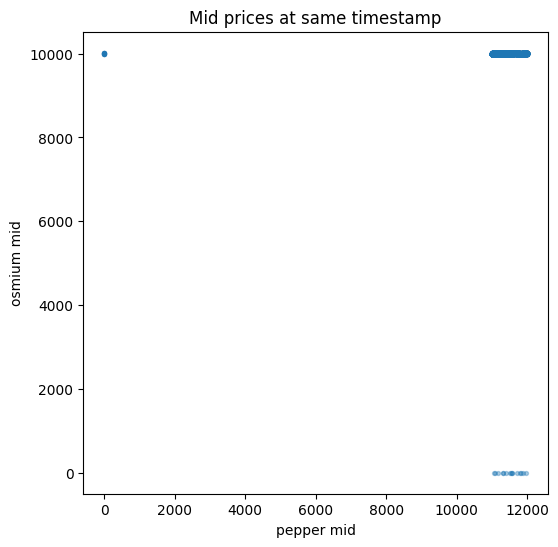

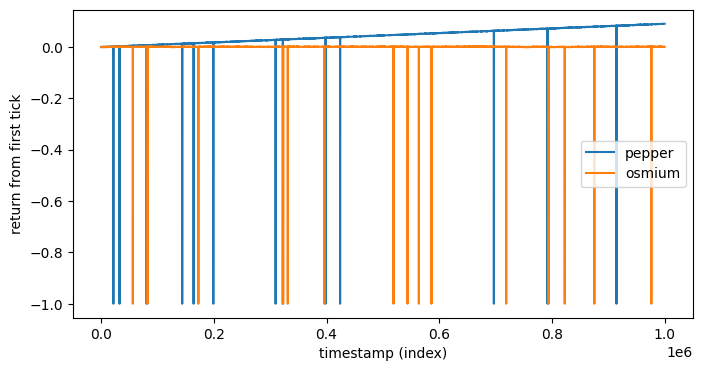

In [19]:
p = pepper[["mid_price"]].rename(columns={"mid_price": "pepper_mid"})
o = osmium[["mid_price"]].rename(columns={"mid_price": "osmium_mid"})
m = p.join(o, how="inner")

# Separate figures — otherwise the 2nd plot reuses the same axes and rescales,
# making the scatter (10k-scale) invisible.

fig1, ax1 = plt.subplots(figsize=(6, 6))
ax1.scatter(m["pepper_mid"], m["osmium_mid"], alpha=0.35, s=8)
ax1.set_xlabel("pepper mid")
ax1.set_ylabel("osmium mid")
ax1.set_title("Mid prices at same timestamp")
plt.show()


def norm(s):
    return (s - s.iloc[0]) / s.iloc[0]


fig2, ax2 = plt.subplots(figsize=(8, 4))
norm(pepper.mid_price).plot(ax=ax2, label="pepper")
norm(osmium.mid_price).plot(ax=ax2, label="osmium")
ax2.legend()
ax2.set_ylabel("return from first tick")
ax2.set_xlabel("timestamp (index)")
plt.show()

(11600.0, 11800.0)

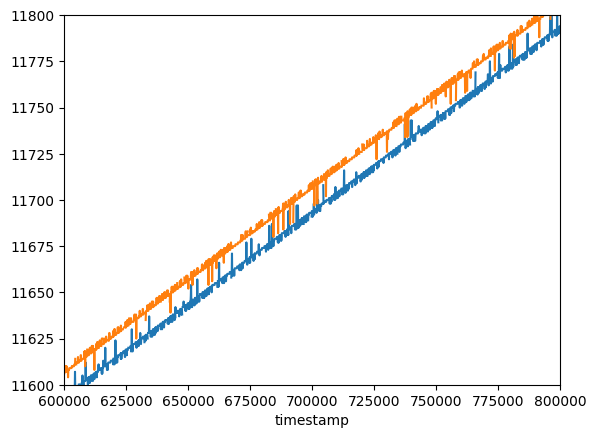

In [20]:
pepper.bid_price_1.plot()
pepper.ask_price_1.plot()
plt.xlim(600000, 800000)
plt.ylim(11600, 11800)


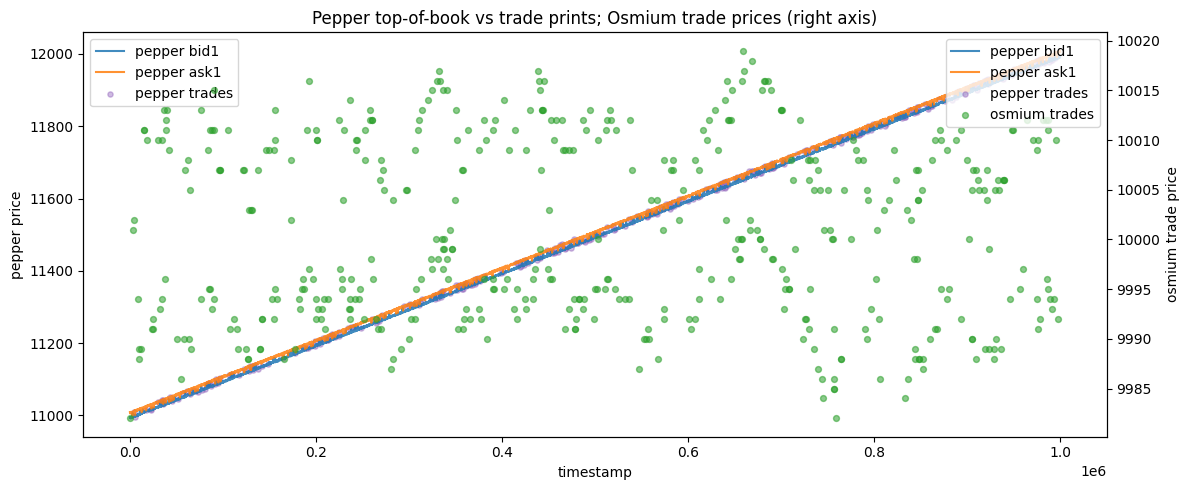

In [23]:

trade = pd.read_csv("../trades_round_2_day_-1.csv", sep=";")
osmium_trades = trade.loc[trade["symbol"] == "ASH_COATED_OSMIUM"]
pepper_trades = trade.loc[trade["symbol"] == "INTARIAN_PEPPER_ROOT"]

fig, ax_pep = plt.subplots(figsize=(12, 5))

ax_pep.plot(pepper.index, pepper["bid_price_1"], label="pepper bid1", alpha=0.85)
ax_pep.plot(pepper.index, pepper["ask_price_1"], label="pepper ask1", alpha=0.85)
if len(pepper_trades):
    ax_pep.scatter(
        pepper_trades["timestamp"],
        pepper_trades["price"],
        s=14,
        alpha=0.45,
        color="tab:purple",
        label="pepper trades",
    )

ax_pep.set_ylabel("pepper price")
ax_pep.set_xlabel("timestamp")
ax_pep.legend(loc="upper left")

ax_osm = ax_pep.twinx()
ax_osm.scatter(
    osmium_trades["timestamp"],
    osmium_trades["price"],
    s=18,
    alpha=0.55,
    color="tab:green",
    label="osmium trades",
)
ax_osm.set_ylabel("osmium trade price")

h1, l1 = ax_pep.get_legend_handles_labels()
h2, l2 = ax_osm.get_legend_handles_labels()
ax_osm.legend(h1 + h2, l1 + l2, loc="upper right")
plt.title("Pepper top-of-book vs trade prints; Osmium trade prices (right axis)")
plt.tight_layout()
plt.show()


### `fig, ax_pep = plt.subplots(figsize=(12, 5))`

- **`plt.subplots()`** returns two things: a **`Figure`** (`fig`) and one or more **`Axes`** (plotting areas).
- **`fig`** is the whole canvas (size, saving to file, `tight_layout()`, etc.).
- **`ax_pep`** is a single subplot: you draw on it with `ax_pep.plot(...)`, `ax_pep.set_xlabel(...)`, etc. Using the explicit `ax` style is clearer than `plt.plot()` when you have multiple subplots or twin axes.
- **`figsize=(12, 5)`** sets width × height in **inches** (12 wide, 5 tall). Bigger figures are easier to read for long time series.

Below: how **`prices_round_2_*.csv`** differs from **`trades_round_2_*.csv`** (schema, density, what to use each for).


=== PRICES (full book snapshot each tick) ===
shape: (20000, 17)
columns: ['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1', 'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3', 'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2', 'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss']
   day  timestamp               product  bid_price_1  bid_volume_1  bid_price_2  bid_volume_2  bid_price_3  bid_volume_3  ask_price_1  ask_volume_1  ask_price_2  ask_volume_2  ask_price_3  ask_volume_3  mid_price  profit_and_loss
0   -1          0  INTARIAN_PEPPER_ROOT      10994.0           9.0          NaN           NaN          NaN           NaN      11009.0          25.0          NaN           NaN          NaN           NaN    11001.5              0.0
1   -1          0     ASH_COATED_OSMIUM       9982.0          21.0          NaN           NaN          NaN           NaN      10000.0          13.0      10003.0          21.0          NaN           NaN     9991.0   

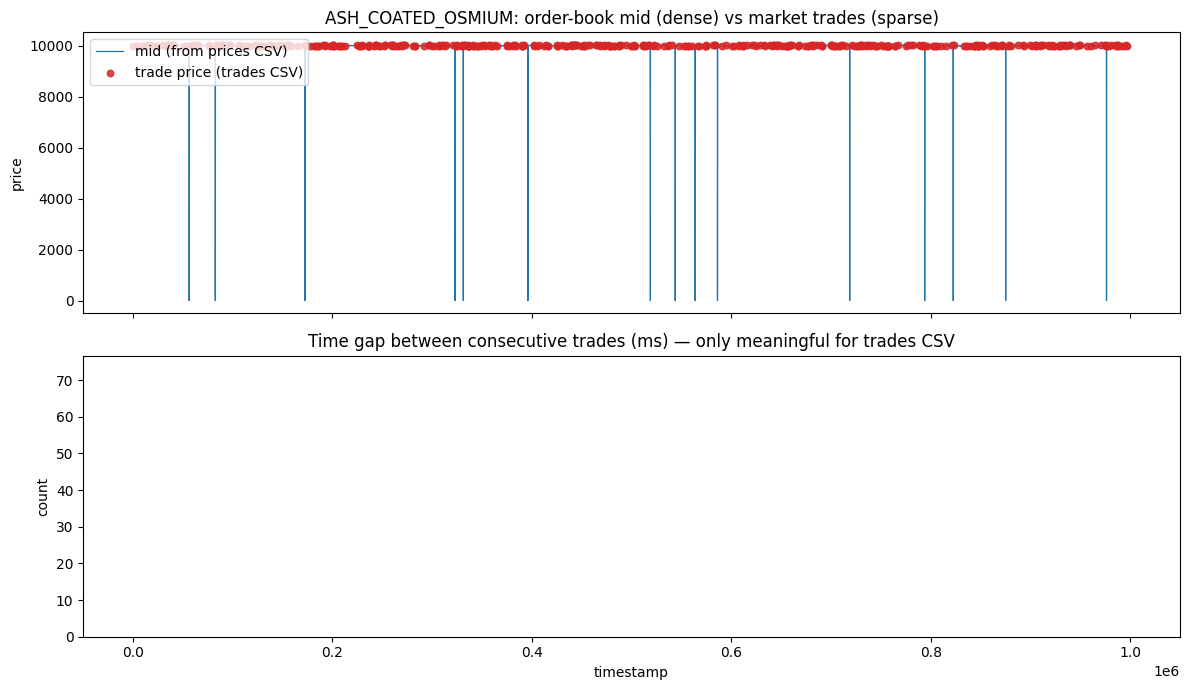

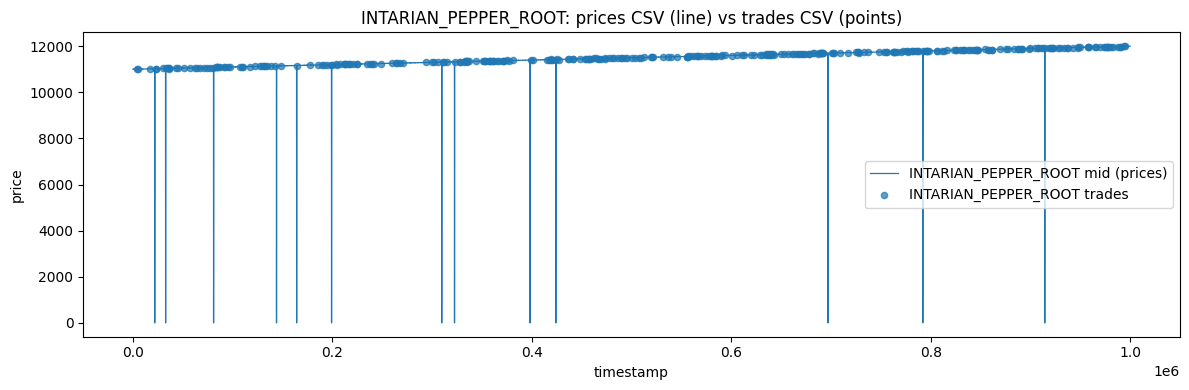

In [25]:
# --- Prices CSV vs Trades CSV (same simulated day) ---
# PRICES: snapshot of the L3 order book + mid every simulation tick (~100ms), for EACH product.
# TRADES: only rows where at least one market trade occurred; sparse; column is "symbol" not "product".

DAY = -1
prices = pd.read_csv(f"../prices_round_2_day_{DAY}.csv", sep=";")
trades = pd.read_csv(f"../trades_round_2_day_{DAY}.csv", sep=";")

def summarize(name: str, df: pd.DataFrame) -> None:
    print(f"\n=== {name} ===")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    print(df.head(3).to_string())

summarize("PRICES (full book snapshot each tick)", prices)
summarize("TRADES (market prints only)", trades)

# Side-by-side model: same symbol, same time axis
sym = "ASH_COATED_OSMIUM"
p = prices.loc[prices["product"] == sym].sort_values("timestamp").reset_index(drop=True)
t = trades.loc[trades["symbol"] == sym].sort_values("timestamp")



fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(p["timestamp"], p["mid_price"], color="C0", lw=0.9, label="mid (from prices CSV)")
if len(t):
    axes[0].scatter(t["timestamp"], t["price"], color="C3", s=22, alpha=0.85, zorder=5, label="trade price (trades CSV)")
axes[0].set_ylabel("price")
axes[0].set_title(f"{sym}: order-book mid (dense) vs market trades (sparse)")
axes[0].legend(loc="upper left")

if len(t) > 1:
    dt = t["timestamp"].diff().dropna()
    axes[1].hist(dt, bins=40, color="C2", edgecolor="white")
    axes[1].set_ylabel("count")
    axes[1].set_title("Time gap between consecutive trades (ms) — only meaningful for trades CSV")
else:
    axes[1].text(0.5, 0.5, "Not enough trades for histogram", ha="center", va="center", transform=axes[1].transAxes)

axes[-1].set_xlabel("timestamp")
plt.tight_layout()
plt.show()

# Second symbol (pepper) — different price level; twin-y if overlaid with osmium
sym2 = "INTARIAN_PEPPER_ROOT"
p2 = prices.loc[prices["product"] == sym2].sort_values("timestamp")
t2 = trades.loc[trades["symbol"] == sym2].sort_values("timestamp")

fig2, ax = plt.subplots(figsize=(12, 4))
ax.plot(p2["timestamp"], p2["mid_price"], lw=0.9, label=f"{sym2} mid (prices)")
if len(t2):
    ax.scatter(t2["timestamp"], t2["price"], s=20, alpha=0.7, label=f"{sym2} trades")
ax.set_xlabel("timestamp")
ax.set_ylabel("price")
ax.legend()
ax.set_title("INTARIAN_PEPPER_ROOT: prices CSV (line) vs trades CSV (points)")
plt.tight_layout()
plt.show()
